## Elección del modelo de clasificación🔬 

En este notebook testeo posibles algoritmos de clasificación una vez obtenidas las caras vectorizadas y con sus respectivos labels de emoción.

Pruebo los distintos modelos...

- Supervisado:
    - KNN
    - SVM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm


In [ ]:
def _load_faces(dir: str) -> pd.DataFrame:    
    angry_faces = pd.read_csv(f"{dir}/angry_faces.csv", header=None).values
    happy_faces = pd.read_csv(f"{dir}/happy_faces.csv", header=None).values
    sad_faces = pd.read_csv(f"{dir}/sad_faces.csv", header=None).values
    surprised_faces = pd.read_csv(f"{dir}/surprise_faces.csv", header=None).values
    neutral_faces = pd.read_csv(f"{dir}/neutral_faces.csv", header=None).values
    disgusted_faces = pd.read_csv(f"{dir}/disgust_faces.csv", header=None).values

    #concat every  face into a single matrix with its corresponding label
    _faces = np.concatenate([
        angry_faces,
        happy_faces,
        sad_faces,
        surprised_faces,    
        neutral_faces,
        disgusted_faces
    ], axis=0)

    #labels for each face
    labels = np.concatenate([
        np.full(angry_faces.shape[0], "angry"),
        np.full(happy_faces.shape[0], "happy"),
        np.full(sad_faces.shape[0], "sad"),
        np.full(surprised_faces.shape[0], "surprised"),
        np.full(neutral_faces.shape[0], "neutral"),
        np.full(disgusted_faces.shape[0], "disgusted")
    ], axis=0)

    faces_df = pd.DataFrame(_faces)

    # if last column is not label, add it
    if faces_df[faces_df.columns[-1]].dtype != object:
        faces_df['label'] = labels
    else:
        faces_df.rename(columns={faces_df.columns[-1]: 'label'}, inplace=True)

    return faces_df

lbp_faces = _load_faces("../data/lbp_faces")

### Preprocess

In [17]:
# configs
_pca_active = True
_normalize_X = True
data = lbp_faces

In [18]:
X, Y = data.iloc[:, :-1].values, data['label'].values
if _normalize_X:
    X = X / 255.0  # normalize pixel values to [0, 1]

##### Dimensionality Reduction

In [21]:
if _pca_active:
    pca = PCA(n_components=100)
    X = pca.fit_transform(X)

#### Split Train, Test

In [22]:
ros = RandomOverSampler(random_state=30)
X_bal, Y_bal = ros.fit_resample(X, Y)

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, 
    Y_bal, 
    test_size=0.2, 
    random_state=30,
    stratify=Y_bal
)
X_train.shape, y_train.shape

((43147, 100), (43147,))

In [23]:
print(pd.Series(y_train).value_counts())

neutral     7192
angry       7191
happy       7191
sad         7191
surprise    7191
disgust     7191
Name: count, dtype: int64


In [24]:
print(pd.Series(y_test).value_counts())

angry       1798
sad         1798
surprise    1798
happy       1798
disgust     1798
neutral     1797
Name: count, dtype: int64


### Función para visualizar matrices de confusión

In [25]:
def plot_confusion_matrix(y_true, y_pred, model_name, class_names=None):
    """
    Visualiza la matriz de confusión para un modelo dado.
    
    Parameters:
    -----------
    y_true : array-like
        Etiquetas verdaderas
    y_pred : array-like
        Predicciones del modelo
    model_name : str
        Nombre del modelo para el título
    class_names : array-like, optional
        Nombres de las clases. Si es None, se usan las clases únicas de y_true
    """
    cm = confusion_matrix(y_true, y_pred)
    
    if class_names is None:
        class_names = sorted(np.unique(np.concatenate([y_true, y_pred])))
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names,
                cbar_kws={'label': 'Cantidad'})
    plt.title(f'Matriz de Confusión - {model_name}', fontsize=16, fontweight='bold')
    plt.ylabel('Etiqueta Real', fontsize=12)
    plt.xlabel('Etiqueta Predicha', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Imprimir métricas adicionales
    print(f"\n{'='*60}")
    print(f"Reporte de Clasificación - {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names))
    print(f"{'='*60}\n")

### KNN

Precisión KNN: 0.6136


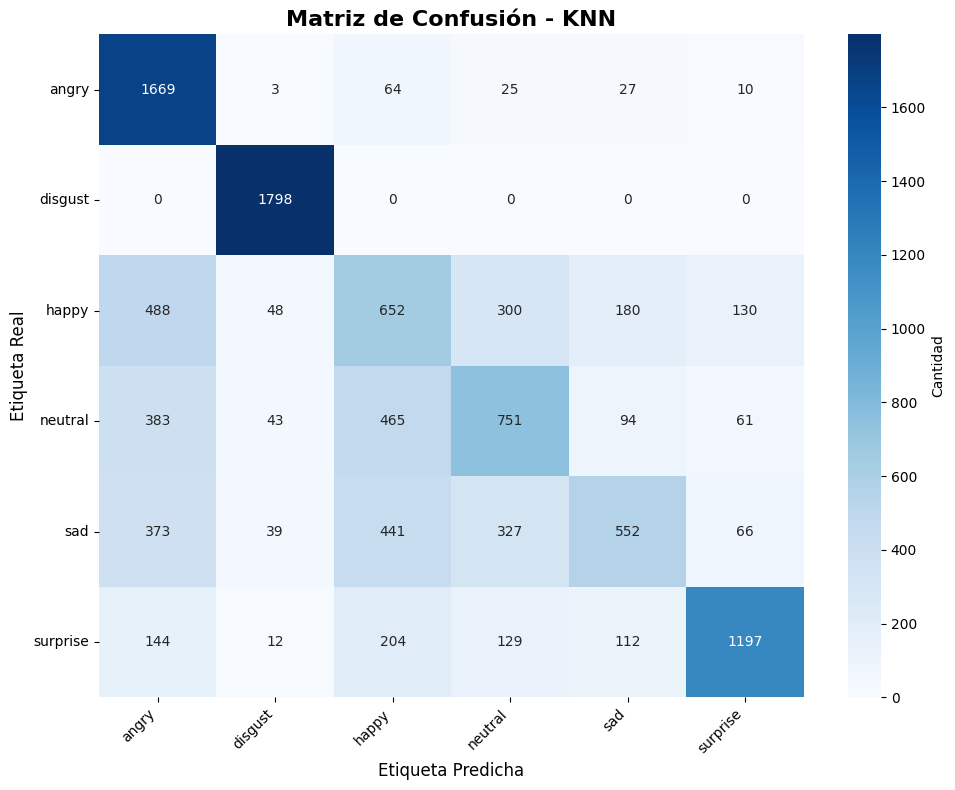


Reporte de Clasificación - KNN
              precision    recall  f1-score   support

       angry       0.55      0.93      0.69      1798
     disgust       0.93      1.00      0.96      1798
       happy       0.36      0.36      0.36      1798
     neutral       0.49      0.42      0.45      1797
         sad       0.57      0.31      0.40      1798
    surprise       0.82      0.67      0.73      1798

    accuracy                           0.61     10787
   macro avg       0.62      0.61      0.60     10787
weighted avg       0.62      0.61      0.60     10787




In [30]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

# Predicciones y score
y_pred_knn = knn.predict(X_test)
knn_accuracy = knn.score(X_test, y_test)
print(f"Precisión KNN: {knn_accuracy:.4f}")

# Visualizar matriz de confusión
plot_confusion_matrix(y_test, y_pred_knn, "KNN")

### SVM


Precisión SVM: 0.2433


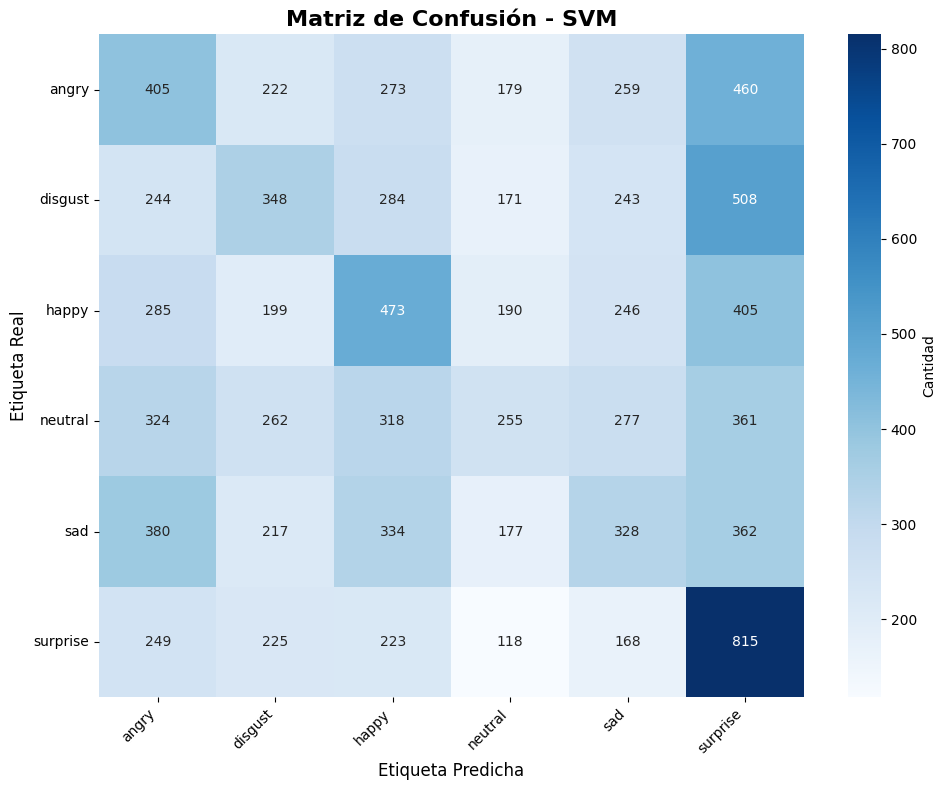


Reporte de Clasificación - SVM
              precision    recall  f1-score   support

       angry       0.21      0.23      0.22      1798
     disgust       0.24      0.19      0.21      1798
       happy       0.25      0.26      0.26      1798
     neutral       0.23      0.14      0.18      1797
         sad       0.22      0.18      0.20      1798
    surprise       0.28      0.45      0.35      1798

    accuracy                           0.24     10787
   macro avg       0.24      0.24      0.23     10787
weighted avg       0.24      0.24      0.23     10787




In [27]:
from sklearn import svm

svm_clf = svm.SVC(kernel='linear')
svm_clf.fit(X_train, y_train)

# Predicciones y score
y_pred_svm = svm_clf.predict(X_test)
svm_accuracy = svm_clf.score(X_test, y_test)
print(f"Precisión SVM: {svm_accuracy:.4f}")

# Visualizar matriz de confusión
plot_confusion_matrix(y_test, y_pred_svm, "SVM")